In [7]:
import pandas as pd
import numpy as np

In [8]:
df=pd.read_csv("C:/Users/RAKSHITH.LAPTOP-FM0GREEU/Downloads/processed_data.csv")
display(df.head())

,review,sentiment,review_tokens_cleaned
0,if you enjoy the original snl cast and shows t...,0,"['enjoy', 'original', 'snl', 'cast', 'shows', ..."
1,a very tired looking burt reynolds plays a mer...,0,"['tired', 'looking', 'burt', 'reynolds', 'play..."
2,first of all if your a fan of the comic well y...,0,"['first', 'fan', 'comic', 'well', 'youll', 'di..."
3,it was all over with the slashers around 88 so...,0,"['slashers', 'around', '88', 'time', 'cheesy',..."
4,i really tried to like this movie it deals wit...,0,"['really', 'tried', 'like', 'movie', 'deals', ..."


In [9]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Shape of training data: {train_df.shape}")
print(f"Shape of testing data: {test_df.shape}")

display(train_df.head())
display(test_df.head())

Shape of training data: (39664, 3)
Shape of testing data: (9917, 3)


,review,sentiment,review_tokens_cleaned
35251,this film is a cash in a cash in reliant on a ...,0,"['film', 'cash', 'cash', 'reliant', 'rousing',..."
3446,this is not a very good telling of the tarzan ...,0,"['good', 'telling', 'tarzan', 'epic', 'one', '..."
24375,i wont repeat all that has been said already b...,1,"['wont', 'repeat', 'said', 'already', 'viewers..."
47963,after the lead actress of the opera is killed ...,1,"['lead', 'actress', 'opera', 'killed', 'car', ..."
8156,br br attack of the killer tomatoes is a parod...,0,"['br', 'br', 'attack', 'killer', 'tomatoes', '..."


,review,sentiment,review_tokens_cleaned
46257,the connection with james deanin a short plan ...,1,"['connection', 'james', 'deanin', 'short', 'pl..."
34141,spoiler alert my boyfriend some friends and i ...,0,"['spoiler', 'alert', 'boyfriend', 'friends', '..."
46337,br br existenz is simply david cronenbergs bes...,1,"['br', 'br', 'existenz', 'simply', 'david', 'c..."
32801,being a huge street fighter fan and thoroughly...,0,"['huge', 'street', 'fighter', 'fan', 'thorough..."
43149,spoilers spoilers i loved the setup and consis...,1,"['spoilers', 'spoilers', 'loved', 'setup', 'co..."


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features as needed

# Fit the vectorizer on the training data 'review' column and transform it
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['review'])

# Transform the testing data 'review' column
X_test_tfidf = tfidf_vectorizer.transform(test_df['review'])

# Display the shapes of the resulting TF-IDF matrices
print(f"Shape of TF-IDF matrix for training data: {X_train_tfidf.shape}")
print(f"Shape of TF-IDF matrix for testing data: {X_test_tfidf.shape}")

Shape of TF-IDF matrix for training data: (39664, 5000)
Shape of TF-IDF matrix for testing data: (9917, 5000)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Define target variables
y_train = train_df['sentiment']
y_test = test_df['sentiment']

# Initialize and train a Logistic Regression model
lr_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
lr_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluate the model
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4984
           1       0.89      0.91      0.90      4933

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



In [12]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Initialize and train a Linear SVM model
svm_model = LinearSVC(random_state=42, dual=True) # dual=True is default and usually good for n_samples > n_features
svm_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluate the model
print("Linear SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4984
           1       0.88      0.90      0.89      4933

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Initialize and train a Multinomial Naive Bayes model
mnb_model = MultinomialNB()
mnb_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred_mnb = mnb_model.predict(X_test_tfidf)

# Evaluate the model
print("Multinomial Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_mnb))

Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      4984
           1       0.85      0.86      0.86      4933

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Define the features (X) and target (y) from the original DataFrame
X = df['review']
y = df['sentiment']

# Initialize Stratified K-Fold for 5 splits
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Performing 5-fold cross-validation...")

# --- Logistic Regression with Pipeline ---
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)), # Use same max_features as before
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

lr_cv_scores = cross_val_score(lr_pipeline, X, y, cv=stratified_kfold, scoring='accuracy', n_jobs=-1)
print(f"\nLogistic Regression (5-fold CV) Mean Accuracy: {lr_cv_scores.mean():.4f}")
print(f"All LR CV Scores: {lr_cv_scores}")

# --- Linear SVM with Pipeline ---
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('classifier', LinearSVC(random_state=42, dual=True))
])

svm_cv_scores = cross_val_score(svm_pipeline, X, y, cv=stratified_kfold, scoring='accuracy', n_jobs=-1)
print(f"\nLinear SVM (5-fold CV) Mean Accuracy: {svm_cv_scores.mean():.4f}")
print(f"All SVM CV Scores: {svm_cv_scores}")

# --- Multinomial Naive Bayes with Pipeline ---
mnb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('classifier', MultinomialNB())
])

mnb_cv_scores = cross_val_score(mnb_pipeline, X, y, cv=stratified_kfold, scoring='accuracy', n_jobs=-1)
print(f"\nMultinomial Naive Bayes (5-fold CV) Mean Accuracy: {mnb_cv_scores.mean():.4f}")
print(f"All MNB CV Scores: {mnb_cv_scores}")

Performing 5-fold cross-validation...

Logistic Regression (5-fold CV) Mean Accuracy: 0.8900
All LR CV Scores: [0.89512958 0.89300121 0.88432836 0.89037919 0.88725292]

Linear SVM (5-fold CV) Mean Accuracy: 0.8880
All SVM CV Scores: [0.89341535 0.89249697 0.88079871 0.88957241 0.88382412]

Multinomial Naive Bayes (5-fold CV) Mean Accuracy: 0.8542
All MNB CV Scores: [0.86044167 0.85407422 0.85246067 0.85538524 0.84852763]


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("Performing hyperparameter tuning for Logistic Regression...")

# Define a pipeline for Logistic Regression
# We'll use a new TfidfVectorizer instance within the pipeline to avoid data leakage
# if we were to further split data or use this pipeline on raw text.
# However, for GridSearchCV, it's often more efficient to define the pipeline directly.
lr_tuning_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('classifier', LogisticRegression(random_state=42))
])

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'classifier__C': [0.1, 1, 10], # Inverse of regularization strength; smaller values specify stronger regularization
    'classifier__solver': ['liblinear', 'saga'] # Solvers that work well with L1/L2 regularization
}

# Initialize GridSearchCV
# We'll use the same stratified_kfold from before for consistent CV splits
grid_search_lr = GridSearchCV(lr_tuning_pipeline, param_grid_lr, cv=stratified_kfold, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit the grid search to the training data (original X and y for CV)
grid_search_lr.fit(X, y)

# Print the best parameters and best score
print(f"\nBest parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best cross-validation accuracy for Logistic Regression: {grid_search_lr.best_score_:.4f}")

Performing hyperparameter tuning for Logistic Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best parameters for Logistic Regression: {'classifier__C': 1, 'classifier__solver': 'saga'}
Best cross-validation accuracy for Logistic Regression: 0.8901


In [16]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Calculate metrics for Logistic Regression
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')

# Calculate metrics for Linear SVM
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')

# Calculate metrics for Multinomial Naive Bayes
mnb_acc = accuracy_score(y_test, y_pred_mnb)
mnb_f1 = f1_score(y_test, y_pred_mnb, average='macro')

# Create a comparison DataFrame
comparison_data = {
    'Model': ['Logistic Regression', 'Linear SVM', 'Multinomial Naive Bayes'],
    'Accuracy': [lr_acc, svm_acc, mnb_acc],
    'Macro F1-Score': [lr_f1, svm_f1, mnb_f1]
}

comparison_df = pd.DataFrame(comparison_data)

# Display the comparison table
display(comparison_df.style.format({
    'Accuracy': '{:.4%}',
    'Macro F1-Score': '{:.4%}'
}))

,Model,Accuracy,Macro F1-Score
0,Logistic Regression,89.9264%,89.9262%
1,Linear SVM,89.2609%,89.2606%
2,Multinomial Naive Bayes,85.7215%,85.7214%


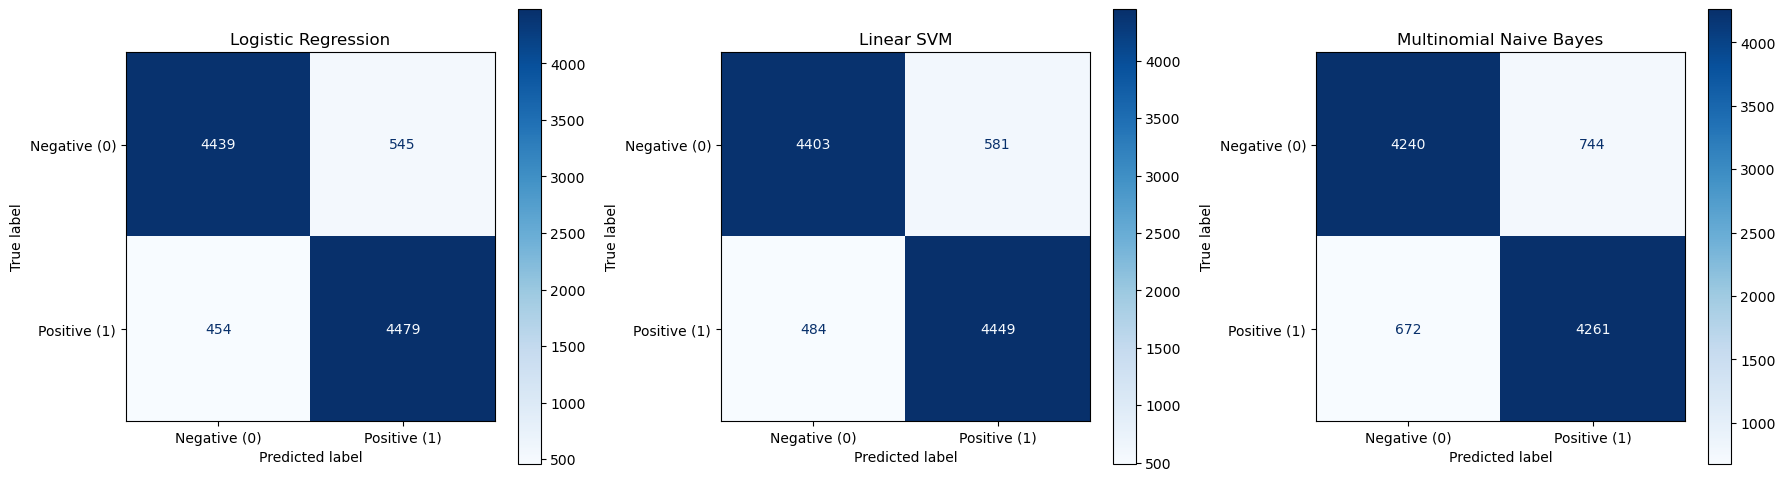

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set up the plotting area with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot Logistic Regression Confusion Matrix ---
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Negative (0)', 'Positive (1)'])
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression')

# --- Plot Linear SVM Confusion Matrix ---
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Negative (0)', 'Positive (1)'])
disp_svm.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Linear SVM')

# --- Plot Multinomial Naive Bayes Confusion Matrix ---
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
disp_mnb = ConfusionMatrixDisplay(confusion_matrix=cm_mnb, display_labels=['Negative (0)', 'Positive (1)'])
disp_mnb.plot(ax=axes[2], cmap='Blues', values_format='d')
axes[2].set_title('Multinomial Naive Bayes')

plt.tight_layout()
plt.show()

In [18]:
# Input and target
X = df["review"]
y = df["sentiment"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text into numerical TF-IDF features
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(
    random_state=42,
    solver="liblinear"
)

# Train the model
model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [19]:
# Generate predictions
prediction = model.predict(X_test_tfidf)

# Generate probability of positive class
probability_positive = model.predict_proba(X_test_tfidf)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(prediction))

Predictions generated successfully.
Number of predictions: 9917


In [20]:
# Display probabilities for both negative and positive classes
model.predict_proba(X_test_tfidf)

array([[0.99825516, 0.00174484],
       [0.1276731 , 0.8723269 ],
       [0.331057  , 0.668943  ],
       ...,
       [0.01476856, 0.98523144],
       [0.90728301, 0.09271699],
       [0.30384922, 0.69615078]])

In [21]:
# Import pandas for creating the analytical DataFrame
import pandas as pd

# Combine actual sentiment, model prediction and positive probability
ae_df = pd.DataFrame({
    "actual_sentiment": y_test.values,       # Actual sentiment from the test dataset
    "prediction": prediction,                # Sentiment predicted by the model
    "probability_positive": probability_positive  # Model's positive probability
})

# Display the first few rows of the analytical dataset
print(ae_df.head())

   actual_sentiment  prediction  probability_positive
0                 0           0              0.001745
1                 1           1              0.872327
2                 1           1              0.668943
3                 0           0              0.165725
4                 0           0              0.026993


In [22]:
prediction = model.predict(X_test_tfidf)
probability_positive = model.predict_proba(X_test_tfidf)[:, 1]
ae_df.head()

,actual_sentiment,prediction,probability_positive
0,0,0,0.001745
1,1,1,0.872327
2,1,1,0.668943
3,0,0,0.165725
4,0,0,0.026993


In [23]:
# Check what columns currently exist in ae_df
print(ae_df.columns.tolist())

['actual_sentiment', 'prediction', 'probability_positive']


Confusion Matrix:
[[4338  602]
 [ 394 4583]]


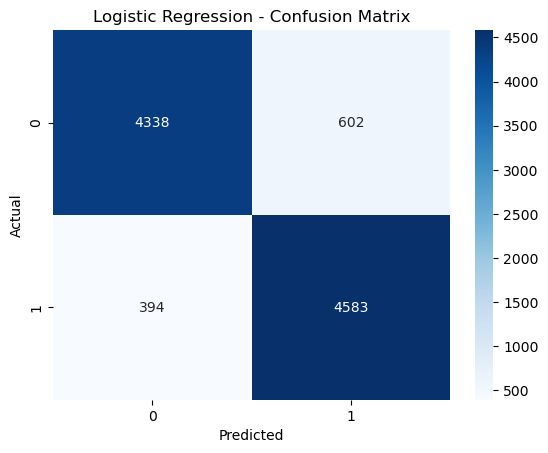

In [24]:
# Import confusion matrix from Scikit-learn
from sklearn.metrics import confusion_matrix

# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Compare actual sentiment with predicted sentiment
cm = confusion_matrix(
    ae_df["actual_sentiment"],
    ae_df["prediction"]
)

# Display the numerical confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix as a heatmap
sns.heatmap(
    cm,
    annot=True,       # Display values inside the matrix
    fmt="d",          # Display values as integers
    cmap="Blues"      # Color style for visualization
)

# Label the axes
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Give the chart a title
plt.title("Logistic Regression - Confusion Matrix")

# Display the chart
plt.show()

In [25]:
# Extract the four values from the confusion matrix
TN, FP, FN, TP = cm.ravel()

# Display True Negative count
print("True Negative :", TN)

# Display False Positive count
print("False Positive:", FP)

# Display False Negative count
print("False Negative:", FN)

# Display True Positive count
print("True Positive :", TP)

True Negative : 4338
False Positive: 602
False Negative: 394
True Positive : 4583


In [28]:
# Calculate Type I error rate using False Positives
type_1_error_rate = FP / (FP + TN)

# Calculate Type II error rate using False Negatives
type_2_error_rate = FN / (FN + TP)

# Display Type I error rate
print("Type I Error Rate :", type_1_error_rate)

# Display Type II error rate
print("Type II Error Rate:", type_2_error_rate)

Type I Error Rate : 0.12186234817813765
Type II Error Rate: 0.0791641551135222


In [30]:
print("Type I Error Rate:",
      round(type_1_error_rate * 100, 2), "%")

print("Type II Error Rate:",
      round(type_2_error_rate * 100, 2), "%")

Type I Error Rate: 12.19 %
Type II Error Rate: 7.92 %


In [31]:
# Assign a business cost of ₹5 to every False Positive
FP_cost = 5

# Assign a business cost of ₹10 to every False Negative
FN_cost = 10

# Calculate the total business cost of model errors
business_cost = (FP * FP_cost) + (FN * FN_cost)

# Display the total business cost
print("Business Cost: ₹", business_cost)

Business Cost: ₹ 6950


In [39]:
# Define the thresholds to evaluate
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

# Loop through every selected threshold
for threshold in thresholds:

    # Generate predictions using the current threshold
    threshold_prediction = (
        ae_df["probability_positive"] >= threshold
    ).astype(int)

    # Calculate the confusion matrix
    cm = confusion_matrix(
        ae_df["actual_sentiment"],
        threshold_prediction
    )

    TN, FP, FN, TP = cm.ravel()

    # Calculate business cost
    business_cost = (FP * 5) + (FN * 10)

    results.append({
        "Threshold": threshold,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
        "Total_Cost": business_cost
    })

# Create results table
results_df = pd.DataFrame(results)

print(results_df)

   Threshold    TN    FP    FN    TP  Total_Cost
0        0.3  3511  1429   119  4858        8335
1        0.4  3972   968   234  4743        7180
2        0.5  4338   602   394  4583        6950
3        0.6  4579   361   725  4252        9055
4        0.7  4770   170  1168  3809       12530


In [42]:
# Select minimum-cost threshold
best_threshold = results_df.loc[
    results_df["Total_Cost"].idxmin(),
    "Threshold"
]

print("Selected Business Threshold:", best_threshold)

# Final predictions
ae_df["final_prediction"] = (
    ae_df["probability_positive"] >= best_threshold
).astype(int)

print("\nFinal predictions:")
print(ae_df.head())

Selected Business Threshold: 0.5

Final predictions:
   actual_sentiment  prediction  probability_positive  final_prediction
0                 0           0              0.001745                 0
1                 1           1              0.872327                 1
2                 1           1              0.668943                 1
3                 0           0              0.165725                 0
4                 0           0              0.026993                 0
